In [6]:
# -*- coding: utf-8 -*-
"""Example of using PCA for outlier detection
"""
# Author: Yue Zhao <zhaoy@cmu.edu>
# License: BSD 2 clause

from __future__ import division
from __future__ import print_function

import os
import sys

# temporary solution for relative imports in case pyod is not installed
# if pyod is installed, no need to use the following line
sys.path.append(
    os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

from pyod.models.pca import PCA
from pyod.utils.data import generate_data
from pyod.utils.data import evaluate_print
import numpy as np
from pyod.utils.example import visualize

In [22]:
contamination = 0  # percentage of outliers
n_train = 100  # number of training points
n_test = 100  # number of testing points

# Generate sample data
X_train, X_test, y_train, y_test = \
    generate_data(n_train=n_train,
                  n_test=n_test,
                  n_features=20,
                  contamination=contamination,
                  random_state=42)

In [23]:
print(X_train,
      y_train)
print(X_test,
      y_test)

[[6.43365854 5.5091683  5.04469788 ... 5.86930893 4.82256361 7.18593123]
 [5.98049594 6.28356746 6.33258429 ... 5.67376352 5.64370447 7.21564822]
 [6.25760622 4.88869009 4.2626848  ... 5.16427815 4.50406714 4.90993249]
 ...
 [5.52577629 4.3268382  5.45884369 ... 6.14947541 7.08679098 5.33684146]
 [5.9149861  6.76177647 7.68309833 ... 7.04336494 5.57867481 6.80879228]
 [6.16879278 7.37648564 5.90132133 ... 7.49972786 5.42902554 6.26810209]] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[[5.62239682 6.50110178 5.07005779 ... 4.89710414 5.44035803 6.46543689]
 [6.54068931 6.3238704  7.03739392 ... 4.7730838  6.56371728 6.74191927]
 [6.70582027 6.1667417  5.2287215  ... 6.2725435  6.06248643 5.55746596]
 ...
 [6.32076592 5.86001731 5.

In [24]:
from pyod.models.thresholds import FILTER


In [25]:
# train PCA detector
clf_name = 'PCA'
clf = PCA(n_components=5, contamination=FILTER())
clf.fit(X_train)


PCA(contamination=<pythresh.thresholds.filter.FILTER object at 0x000002165240B4C0>,
  copy=True, iterated_power='auto', n_components=5,
  n_selected_components=None, random_state=None, standardization=True,
  svd_solver='auto', tol=0.0, weighted=True, whiten=False)

In [26]:
# get the prediction labels and outlier scores of the training data
y_train_scores = clf.decision_scores_  # raw outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)

print(y_train_scores,
      y_train_pred)

[299.20038529 199.82847474 311.12950908 246.71038557 304.09561788
 286.41330985 264.35678827 221.17366918 233.71656264 338.99276905
 227.12846105 271.3770294  219.23762525 272.44948382 237.52361693
 274.07246683 325.07208869 241.18208613 310.30735879 256.44967219
 238.59464562 282.797608   314.06902032 327.27374711 269.34603792
 206.26147417 360.0836171  299.6325262  284.30508385 326.59053991
 295.02425469 359.72222397 199.88739542 261.35029517 354.40379906
 284.82283138 188.87411976 289.6024171  244.0681229  248.84247794
 232.22536431 333.49842448 271.46355884 193.13353035 265.5266663
 220.73397599 172.79366588 249.61747846 273.91395319 269.7407897
 220.31032056 336.86805023 309.62316913 342.28259009 315.15700545
 324.85956261 236.31411962 211.58148837 312.65653402 325.22660234
 223.62038963 254.752064   249.40873943 357.05711116 261.50218947
 260.31052196 327.83435467 288.4127211  276.18306665 275.35298827
 239.47986373 297.50586561 220.67023531 249.737558   260.55550738
 256.9515947

In [27]:
# get the prediction on the test data

y_test_scores = clf.decision_function(X_test)  # outlier scores
y_test_pred = clf.predict(X_test)  # outlier labels (0 or 1)
print(y_test_scores,
      y_test_pred)

[241.87888571 341.35605653 213.38823177 258.5257837  214.75548726
 200.86276286 278.20022161 267.3119599  211.14223835 321.83390002
 240.29309218 306.89076343 236.61907718 263.39867005 269.17707653
 290.17205707 343.21634516 279.6013896  203.55007809 287.20564367
 307.62716845 266.28824937 276.08671279 323.77752219 272.53022559
 300.49225527 264.55420961 270.61613667 299.30326332 286.78223407
 348.22487419 270.50976541 295.91886197 240.208547   327.40315262
 292.38477465 238.00160705 213.36877721 282.13558455 235.62037244
 261.34999913 215.84071788 361.80576554 248.8563355  221.78317706
 266.87035622 305.50223292 229.91324548 237.33175566 244.03338215
 230.38818891 276.24223324 227.11796893 286.39744524 247.33987816
 328.69210689 194.89873063 254.81738143 256.99682785 357.7146695
 310.72290534 266.23477174 239.48940807 272.77134192 256.28764026
 227.60711337 247.87264921 325.6215575  245.49028683 255.41286659
 298.68370487 260.87405612 357.27944815 209.67631636 280.67340274
 293.953094

In [30]:
from sklearn.metrics import (recall_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score)
def evaluate_print_acc_balacc_recall_f1(clf_name, y, y_pred):

    print('{clf_name}'.format(clf_name=clf_name))
    print("acc:{:.2%}".format(accuracy_score(y, y_pred)))
    print("balancedACC:{:.2%}".format(balanced_accuracy_score(y, y_pred)))
    print("recall:{:.2%}".format(recall_score(y, y_pred)))
    print("f1:{:.2%}".format(f1_score(y, y_pred)))
    print("AUC:{:.2%}".format(roc_auc_score(y, y_pred)))  # AUC 值越接近 1，说明模型的分类效果越好。
evaluate_print_acc_balacc_recall_f1(clf_name, y_test, y_test_pred)

PCA
acc:74.00%
balancedACC:74.00%
recall:0.00%
f1:0.00%


D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [31]:
# evaluate and print the results
print("\nOn Training Data:")
evaluate_print(clf_name, y_train, y_train_scores)
print("\nOn Test Data:")
evaluate_print(clf_name, y_test, y_test_scores)


On Training Data:


ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [32]:

# visualize the results
# Note: the original dimension has to be 2 for visualization
visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred,
          y_test_pred, show_figure=True, save_figure=False)

ValueError: Input data has to be 2-d for visualization. The input data has (100, 20).

In [ ]:
#============================================================================================

In [32]:
import numpy as np
import matplotlib.pyplot as plt

(865, 4) (865,)
[[7.06723922 4.49079088 4.50467675 5.81577993]
 [5.58459125 4.08693108 3.71450441 4.2604754 ]
 [6.81085804 4.03719973 3.76647234 4.44358957]
 ...
 [6.3010892  4.26517166 3.24254603 3.77510651]
 [8.20863157 5.20019334 4.44072292 4.94868702]
 [6.62925722 2.78534852 3.40290711 4.3522574 ]] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

array([0., 0., 0., ..., 1., 1., 1.])

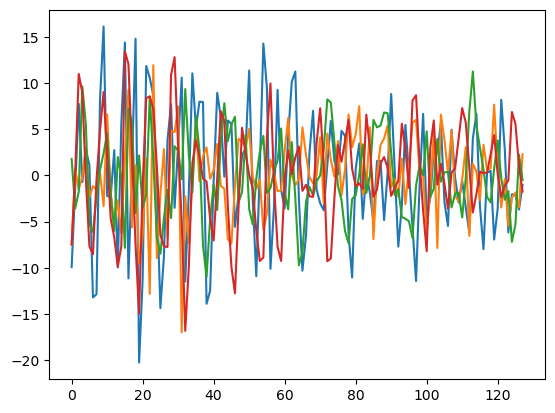

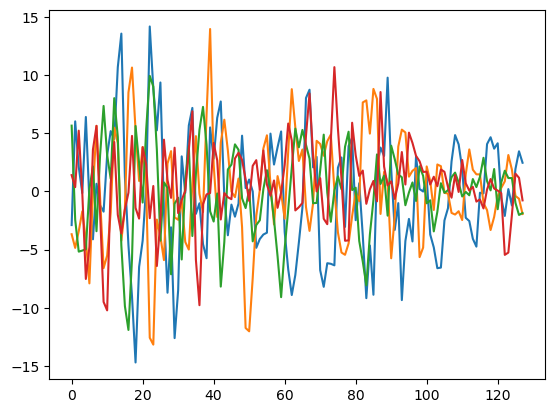

In [37]:
normalData = np.genfromtxt(r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\h30hz50-NEAI - nominal.csv',
                           delimiter=',')
# normalData
normalDataReshape = []
for i in range(normalData.shape[0]):
    row = normalData[i, :]
    row2 = row.reshape(128, 4)
    normalDataReshape.append(row2)
# print(len(normalDataReshape))
# print(normalDataReshape[0])
# print(normalDataReshape[864])
normalDataReshape = np.array(normalDataReshape)
# print(normalDataReshape.shape)
# normalDataReshape
normalLabel = np.zeros(normalData.shape[0])
# normalLabel
abnormalData = np.genfromtxt(
    r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\b30hz50-NEAI - abnormal.csv', delimiter=',')
# abnormalData
abnormalDataReshape = []
for i in range(abnormalData.shape[0]):
    row = abnormalData[i, :]
    row2 = row.reshape(128, 4)
    abnormalDataReshape.append(row2)
# print(len(normalDataReshape))
# print(normalDataReshape[0])
# print(normalDataReshape[864])
abnormalDataReshape = np.array(abnormalDataReshape)
# print(abnormalDataReshape.shape)
# abnormalDataReshape
abnormalLabel = np.ones(abnormalData.shape[0])
# abnormalLabel
# normalDataTrain, normalDataTest, normalLabelTrain, normalLabelTest  = train_test_split(normalDataReshape, normalLabel, test_size=0.01, shuffle=True)
# print(normalDataTrain.shape, normalDataTrain)
# print(normalLabelTrain.shape, normalLabelTrain)
# print(normalDataTest.shape, normalDataTest)
# print(normalLabelTest.shape, normalLabelTest)
xTrain = normalDataReshape
yTrain = normalLabel
xTest = abnormalDataReshape
yTest = abnormalLabel
# print(xTrain.shape, yTrain.shape)
# print(xTrain, '\n', yTrain)
# print(xTest.shape, yTest.shape)
# print(xTest, '\n', yTest)
plt.figure()
plt.plot(xTrain[0])
plt.figure()
plt.plot(xTest[3])
xTrainRMS = np.sqrt(np.mean(np.square(xTrain), axis=1))
xTestRMS = np.sqrt(np.mean(np.square(xTest), axis=1))
print(xTrainRMS.shape, yTrain.shape)
print(xTrainRMS, yTrain)
print(xTestRMS.shape, yTest.shape)
print(xTestRMS, yTest)
allSample = np.concatenate((xTrainRMS, xTestRMS), axis=0)
allSample
allSampleLabel = np.concatenate((yTrain, yTest), axis=0)
allSampleLabel

In [78]:
contamination = 0  # percentage of outliers
n_train = xTrainRMS.shape[0]  # number of training points
n_test = xTestRMS.shape[0]  # number of testing points

# Generate sample data
X_train, X_test, y_train, y_test = \
    generate_data(n_train=n_train,
                  n_test=n_test,
                  n_features=4,
                  contamination=contamination,
                  random_state=42)

In [84]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.knn import KNN

sys.path.append(
    os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

from pyod.models.auto_encoder import AutoEncoder

In [85]:
# train PCA detector
clf_name = 'PCA'
clf = PCA(n_components=4)
# clf = KPCA(n_components=4)
# # clf = KNN()
# clf = IForest()
# clf = AutoEncoder()

clf.fit(xTrainRMS)

# get the prediction labels and outlier scores of the training data
y_train_scores = clf.decision_scores_  # raw outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)

print(y_train_scores,
      y_train_pred)
# get the prediction on the test data

y_test_scores = clf.decision_function(xTestRMS)  # outlier scores
y_test_pred = clf.predict(xTestRMS)  # outlier labels (0 or 1)
print(y_test_scores,
      y_test_pred)


[ 90.87148006  97.44913797  86.89791154  96.52465738  81.34962271
 126.70041738  94.96550369 146.58155341 122.82463095 138.5586315
 146.65264276 192.50482008  73.91767234 168.65016467 443.61858014
 282.43023357 137.42192146  69.41565705 119.80283816 109.49959445
 116.82197796 195.64981746 120.30615686 122.13525091 118.33433835
 127.35290092 105.84788903 178.79216778 124.02480628 121.63153651
 110.71639685 250.97551635 179.10725106 139.20215788 165.99567181
 193.56869728 154.77875723 121.57764075  91.37006857  90.90790597
 168.16186185  95.24031941 186.88394456 207.74453948 243.71027893
 152.55969274 102.05143783 244.90391517 107.98382948  76.89152886
 113.13782976  73.69932295 187.32664538 193.98749928 142.41485714
 101.88183045 110.11904916 248.44263299 101.01899611  73.97143241
 149.23219312 127.46951885 135.73908924 100.99468082 203.96402832
 320.62957435 156.15738056  83.81026485 118.77546729  93.07218659
 101.40746183 104.44219251 121.5458123   79.76530331 140.11501529
 131.930634

In [86]:
from sklearn.metrics import (recall_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score)
def evaluate_print_acc_balacc_recall_f1(clf_name, y, y_pred):
    print('{clf_name}'.format(clf_name=clf_name))
    print("acc:{:.2%}".format(accuracy_score(y, y_pred)))
    print("balancedACC:{:.2%}".format(balanced_accuracy_score(y, y_pred)))
    print("recall:{:.2%}".format(recall_score(y, y_pred)))
    print("f1:{:.2%}".format(f1_score(y, y_pred)))
    print("AUC:{:.2%}".format(roc_auc_score(y, y_pred)))  # AUC 值越接近 1，说明模型的分类效果越好。
evaluate_print_acc_balacc_recall_f1(clf_name, yTest, y_test_pred)
# evaluate and print the results
# print("\nOn Training Data:")
# evaluate_print(clf_name, y_train, y_train_scores)
# print("\nOn Test Data:")
# evaluate_print(clf_name, y_test, y_test_scores)


PCA
acc:5.44%
balancedACC:5.44%
recall:5.44%
f1:10.32%


D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [ ]:

# visualize the results
# Note: the original dimension has to be 2 for visualization
# visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred,
#           y_test_pred, show_figure=True, save_figure=False)

In [ ]:
#================================================================================================noReshape+IPCA

In [107]:
normalData = np.genfromtxt(r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\h30hz50-NEAI - nominal.csv',
                           delimiter=',')
normalData
# normalDataReshape = []
# for i in range(normalData.shape[0]):
#     row = normalData[i,:]
#     row2 = row.reshape(128, 4)
#     normalDataReshape.append(row2)
# # print(len(normalDataReshape))
# # print(normalDataReshape[0])
# # print(normalDataReshape[864])
# normalDataReshape = np.array(normalDataReshape)
# print(normalDataReshape.shape)
# normalDataReshape
normalLabel = np.zeros(normalData.shape[0])
normalLabel
abnormalData = np.genfromtxt(
    r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\b30hz50-NEAI - abnormal.csv', delimiter=',')
abnormalData
# abnormalDataReshape = []
# for i in range(abnormalData.shape[0]):
#     row = abnormalData[i,:]
#     row2 = row.reshape(128, 4)
#     abnormalDataReshape.append(row2)
# # print(len(normalDataReshape))
# # print(normalDataReshape[0])
# # print(normalDataReshape[864])
# abnormalDataReshape = np.array(abnormalDataReshape)
# print(abnormalDataReshape.shape)
# abnormalDataReshape
abnormalLabel = np.ones(abnormalData.shape[0])
abnormalLabel
# normalDataTrain, normalDataTest, normalLabelTrain, normalLabelTest  = train_test_split(normalDataReshape, normalLabel, test_size=0.01, shuffle=True)
# print(normalDataTrain.shape, normalDataTrain)
# print(normalLabelTrain.shape, normalLabelTrain)
# print(normalDataTest.shape, normalDataTest)
# print(normalLabelTest.shape, normalLabelTest)
xTrain = normalData
yTrain = normalLabel
xTest = abnormalData
yTest = abnormalLabel
print(xTrain.shape, yTrain.shape)
print(xTrain, '\n', yTrain)
print(xTest.shape, yTest.shape)
print(xTest, '\n', yTest)

(865, 512) (865,)
[[-9.92015  -7.47519   1.79468  ...  2.29613  -0.486036 -1.73706 ]
 [-1.86466   3.38117   1.3346   ...  5.49065   1.74585   3.38022 ]
 [-8.6539   -0.76361   3.38893  ...  3.32058  -2.36364   4.74699 ]
 ...
 [ 9.47389   1.88312  -0.380576 ... -4.87996   1.18704  -6.21042 ]
 [10.0172   -1.7508   -6.20448  ...  7.19783   1.28263  10.5157  ]
 [16.37     -2.21759   6.49883  ...  2.88723  -1.99567  -1.71478 ]] 
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [102]:
# contamination = 0.5  # percentage of outliers
# n_train = xTrain.shape[0]  # number of training points
# n_test = xTest.shape[0]  # number of testing points
# n_features = 512
# # Generate sample data
# X_train, X_test, y_train, y_test = \
#     generate_data(n_train=n_train,
#                   n_test=n_test,
#                   n_features=n_features,
#                   contamination=contamination,
#                   random_state=42)


In [113]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.knn import KNN

sys.path.append(
    os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

from pyod.models.auto_encoder import AutoEncoder

# train PCA detector
clf_name = 'PCA'
# clf = PCA(n_components=128)
clf = KPCA(n_components=4)
# # clf = KNN()
# clf = IForest()
# clf = AutoEncoder()



In [114]:
clf.fit(xTrain)

# get the prediction labels and outlier scores of the training data
y_train_scores = clf.decision_scores_  # raw outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)

print(y_train_scores,
      y_train_pred)
# get the prediction on the test data

y_test_scores = clf.decision_function(xTest)  # outlier scores
y_test_pred = clf.predict(xTest)  # outlier labels (0 or 1)
print(y_test_scores,
      y_test_pred)


[0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883173
 0.99883172 0.99883172 0.99883172 0.99883173 0.9988317  0.99883176
 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883174
 0.99883166 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172
 0.99883171 0.99883172 0.99883172 0.99883194 0.99883171 0.99883172
 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883171
 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172
 0.99883173 0.9988317  0.99883401 0.99883171 0.99883172 0.99883172
 0.99883172 0.99883172 0.99883172 0.99883172 0.998832   0.99883172
 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172
 0.99883172 0.99883172 0.99883173 0.99883172 0.99883172 0.99883172
 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172
 0.99883172 0.99883172 0.99883172 0.99883173 0.99883172 0.99883168
 0.99882663 0.99883172 0.99883172 0.99883172 0.99883172 0.99883172
 0.99883172 0.99883171 0.99883169 0.99883172 0.99883172 0.9988

In [118]:

from sklearn.metrics import (recall_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score)


def evaluate_print_acc_balacc_recall_f1(clf_name, y, y_pred):
    print('{clf_name}'.format(clf_name=clf_name))
    print("acc:{:.2%}".format(accuracy_score(y, y_pred)))
    print("balancedACC:{:.2%}".format(balanced_accuracy_score(y, y_pred)))
    print("recall:{:.2%}".format(recall_score(y, y_pred)))
    print("f1:{:.2%}".format(f1_score(y, y_pred)))
    # print("AUC:{:.2%}".format(roc_auc_score(y, y_pred)))  # AUC 值越接近 1，说明模型的分类效果越好。


print('train',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTrain, y_train_pred))

print('test',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTest, y_test_pred))

# evaluate and print the results
# print("\nOn Training Data:")
# evaluate_print(clf_name, y_train, y_train_scores)
# print("\nOn Test Data:")
# evaluate_print(clf_name, y_test, y_test_scores)


PCA
acc:89.94%
balancedACC:89.94%
recall:0.00%
f1:0.00%
train None
PCA
acc:100.00%
balancedACC:100.00%
recall:100.00%
f1:100.00%
test None


D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
#================================================================================================noReshape+ae

In [4]:
normalData = np.genfromtxt(r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\h30hz50-NEAI - nominal.csv',
                           delimiter=',')
normalLabel = np.zeros(normalData.shape[0])
abnormalData = np.genfromtxt(
    r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\b30hz50-NEAI - abnormal.csv', delimiter=',')
abnormalLabel = np.ones(abnormalData.shape[0])
xTrain = normalData
yTrain = normalLabel
xTest = abnormalData
yTest = abnormalLabel
print(xTrain.shape, yTrain.shape)
print(xTrain, '\n', yTrain)
print(xTest.shape, yTest.shape)
print(xTest, '\n', yTest)

(865, 512) (865,)
[[-9.92015  -7.47519   1.79468  ...  2.29613  -0.486036 -1.73706 ]
 [-1.86466   3.38117   1.3346   ...  5.49065   1.74585   3.38022 ]
 [-8.6539   -0.76361   3.38893  ...  3.32058  -2.36364   4.74699 ]
 ...
 [ 9.47389   1.88312  -0.380576 ... -4.87996   1.18704  -6.21042 ]
 [10.0172   -1.7508   -6.20448  ...  7.19783   1.28263  10.5157  ]
 [16.37     -2.21759   6.49883  ...  2.88723  -1.99567  -1.71478 ]] 
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [5]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.models.knn import KNN

sys.path.append(
    os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

from pyod.models.auto_encoder import AutoEncoder

# train PCA detector
clf_name = 'ae'
# clf = PCA(n_components=128)
# clf = KPCA(n_components=4)
# # clf = KNN()
# clf = IForest()
clf = AutoEncoder()



In [6]:
clf.fit(xTrain)

# get the prediction labels and outlier scores of the training data
y_train_scores = clf.decision_scores_  # raw outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)

print(y_train_scores,
      y_train_pred)
# get the prediction on the test data

y_test_scores = clf.decision_function(xTest)  # outlier scores
y_test_pred = clf.predict(xTest)  # outlier labels (0 or 1)
print(y_test_scores,
      y_test_pred)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               262656    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 64)                1

In [7]:

from sklearn.metrics import (recall_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score)


def evaluate_print_acc_balacc_recall_f1(clf_name, y, y_pred):
    print('{clf_name}'.format(clf_name=clf_name))
    print("acc:{:.2%}".format(accuracy_score(y, y_pred)))
    print("balancedACC:{:.2%}".format(balanced_accuracy_score(y, y_pred)))
    print("recall:{:.2%}".format(recall_score(y, y_pred)))
    print("f1:{:.2%}".format(f1_score(y, y_pred)))
    # print("AUC:{:.2%}".format(roc_auc_score(y, y_pred)))  # AUC 值越接近 1，说明模型的分类效果越好。


print('train',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTrain, y_train_pred))

print('test',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTest, y_test_pred))


ae
acc:89.94%
balancedACC:89.94%
recall:0.00%
f1:0.00%
train None
ae
acc:0.68%
balancedACC:0.68%
recall:0.68%
f1:1.35%
test None


D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
#================================================================================================noReshape+ae

In [8]:
normalData = np.genfromtxt(r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\h30hz50-NEAI - nominal.csv',
                           delimiter=',')
normalLabel = np.zeros(normalData.shape[0])
abnormalData = np.genfromtxt(
    r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\b30hz50-NEAI - abnormal.csv', delimiter=',')
abnormalLabel = np.ones(abnormalData.shape[0])
xTrain = normalData
yTrain = normalLabel
xTest = abnormalData
yTest = abnormalLabel
print(xTrain.shape, yTrain.shape)
print(xTrain, '\n', yTrain)
print(xTest.shape, yTest.shape)
print(xTest, '\n', yTest)

(865, 512) (865,)
[[-9.92015  -7.47519   1.79468  ...  2.29613  -0.486036 -1.73706 ]
 [-1.86466   3.38117   1.3346   ...  5.49065   1.74585   3.38022 ]
 [-8.6539   -0.76361   3.38893  ...  3.32058  -2.36364   4.74699 ]
 ...
 [ 9.47389   1.88312  -0.380576 ... -4.87996   1.18704  -6.21042 ]
 [10.0172   -1.7508   -6.20448  ...  7.19783   1.28263  10.5157  ]
 [16.37     -2.21759   6.49883  ...  2.88723  -1.99567  -1.71478 ]] 
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [13]:
normalData = np.genfromtxt(r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\h30hz50-NEAI - nominal.csv',
                           delimiter=',')

normalDataReshape = []
for i in range(normalData.shape[0]):
    row = normalData[i, :]
    row2 = row.reshape(128, 4)
    normalDataReshape.append(row2)
normalDataReshape = np.array(normalDataReshape)
normalLabel = np.zeros(normalData.shape[0])
abnormalData = np.genfromtxt(
    r'D:\company\data\NanoEdge AI Studio\NEAI-gearbox-fault-dataset\b30hz50-NEAI - abnormal.csv', delimiter=',')
abnormalDataReshape = []
for i in range(abnormalData.shape[0]):
    row = abnormalData[i, :]
    row2 = row.reshape(128, 4)
    abnormalDataReshape.append(row2)
abnormalDataReshape = np.array(abnormalDataReshape)
abnormalLabel = np.ones(abnormalData.shape[0])
xTrain = normalDataReshape
yTrain = normalLabel
xTest = abnormalDataReshape
yTest = abnormalLabel

xTrainRMS = np.sqrt(np.mean(np.square(xTrain), axis=1))
xTestRMS = np.sqrt(np.mean(np.square(xTest), axis=1))
print(xTrainRMS.shape, yTrain.shape)
print(xTrainRMS, yTrain)
print(xTestRMS.shape, yTest.shape)
print(xTestRMS, yTest)
allSample = np.concatenate((xTrainRMS, xTestRMS), axis=0)
allSample
allSampleLabel = np.concatenate((yTrain, yTest), axis=0)
allSampleLabel

(865, 4) (865,)
[[7.06723922 4.49079088 4.50467675 5.81577993]
 [5.58459125 4.08693108 3.71450441 4.2604754 ]
 [6.81085804 4.03719973 3.76647234 4.44358957]
 ...
 [6.3010892  4.26517166 3.24254603 3.77510651]
 [8.20863157 5.20019334 4.44072292 4.94868702]
 [6.62925722 2.78534852 3.40290711 4.3522574 ]] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

array([0., 0., 0., ..., 1., 1., 1.])

In [14]:
from pyod.models.sos import SOS
clf_name = 'sos'
clf = SOS()

In [15]:
clf.fit(xTrainRMS)

# get the prediction labels and outlier scores of the training data
y_train_scores = clf.decision_scores_  # raw outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)

print(y_train_scores,
      y_train_pred)
# get the prediction on the test data

y_test_scores = clf.decision_function(xTestRMS)  # outlier scores
y_test_pred = clf.predict(xTestRMS)  # outlier labels (0 or 1)
print(y_test_scores,
      y_test_pred)


[0.10164463 0.30363458 0.49720956 0.42317851 0.82064758 0.19817799
 0.1617366  0.44668954 0.42146283 0.16274159 0.16004087 0.23929374
 0.11631618 0.62977847 0.22995414 0.08396767 0.42536615 0.1269961
 0.69419663 0.19566648 0.83062213 0.42476439 0.424976   0.81518531
 0.47388966 0.23573359 0.30655654 0.43743225 0.83644766 0.18385405
 0.26706358 0.07268382 0.14306746 0.78802461 0.06636027 0.13757165
 0.81393261 0.2301581  0.14794603 0.20290706 0.14851708 0.09342057
 0.22233283 0.61810354 0.80236548 0.7990978  0.08586228 0.45823966
 0.16056988 0.66914043 0.10465419 0.16351154 0.26021248 0.09825537
 0.74229031 0.34510224 0.43621183 0.21740352 0.26454565 0.40483311
 0.07051661 0.22218909 0.97666793 0.58499442 0.19237709 0.12293378
 0.33672071 0.49638912 0.68074629 0.13976224 0.14909322 0.61082653
 0.16107852 0.28488709 0.31662988 0.09211362 0.83629852 0.93908777
 0.23718396 0.20157142 0.45444892 0.35839994 0.25841584 0.49391215
 0.14130797 0.88194835 0.60895916 0.43665942 0.31314258 0.17258

In [16]:

from sklearn.metrics import (recall_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score)


def evaluate_print_acc_balacc_recall_f1(clf_name, y, y_pred):
    print('{clf_name}'.format(clf_name=clf_name))
    print("acc:{:.2%}".format(accuracy_score(y, y_pred)))
    print("balancedACC:{:.2%}".format(balanced_accuracy_score(y, y_pred)))
    print("recall:{:.2%}".format(recall_score(y, y_pred)))
    print("f1:{:.2%}".format(f1_score(y, y_pred)))
    # print("AUC:{:.2%}".format(roc_auc_score(y, y_pred)))  # AUC 值越接近 1，说明模型的分类效果越好。


print('train',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTrain, y_train_pred))

print('test',
      evaluate_print_acc_balacc_recall_f1(clf_name, yTest, y_test_pred))


sos
acc:89.94%
balancedACC:89.94%
recall:0.00%
f1:0.00%
train None
sos
acc:9.66%
balancedACC:9.66%
recall:9.66%
f1:17.62%
test None


D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\ProgramFiles\anaconda3\envs\pyod\lib\site-packages\sklearn\metrics\_classification.py:2394: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
